In [1]:
%matplotlib inline

import sys, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/dvm/Documents/DvM')

from open_dvm.analysis import CTF
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_ctf_timecourse

print("✓ Imports successful")

✓ Imports successful


In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}


In [3]:
# check tuning across individual positions
# Load data 
sj = 1
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

ctf_o = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',
    nr_bins=8, nr_chans=8, elec_oi='all', filter=8,
    avg_ch=False, baseline=(-0.2, 0), downsample=128,
    shift_bins = df.high_prob_dist.iloc[0]
)

ctfs, ctf_param, _ = ctf_o.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=['localizer']),
    window_oi=(-0.2, 0.5), freqs='broadband'
)

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Freque

Times converted from seconds to milliseconds
not enough colors specified. Using default colors


/Users/dvm/Documents/DvM/open_dvm/visualization/plot.py:1781: UserWarning: Statistical testing with individual bins (plot_bins=True) is not yet supported. Statistics will be skipped for binned data. Set plot_bins=False to enable significance testing.
  warnings.warn('Statistical testing with individual bins (plot_bins=True) '


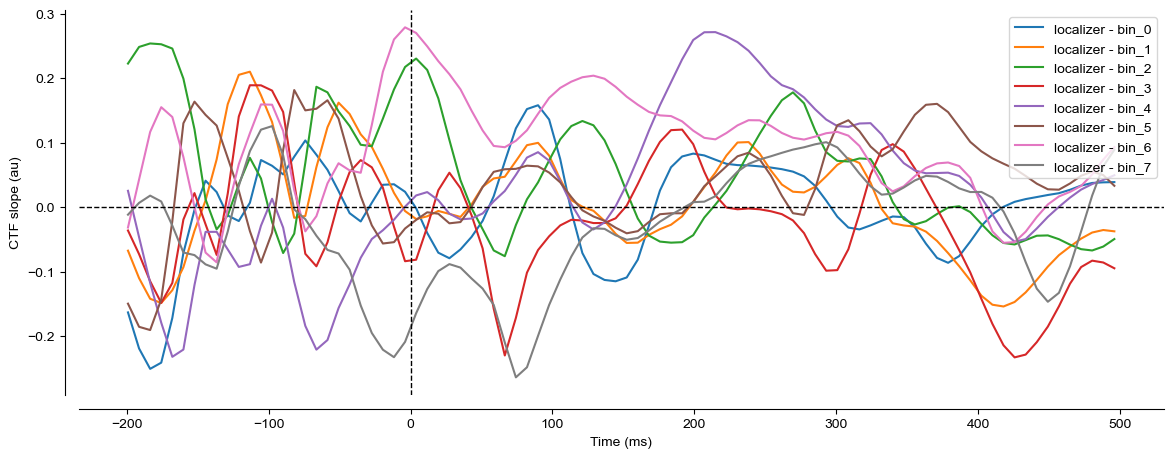

In [4]:
fig = plt.figure(figsize=(14, 5))
plot_ctf_timecourse(ctf_param, output = 'voltage_slopes',plot_bins=True, timecourse = '1d', stats = 'perm')

plt.legend()
display(fig)

In [5]:
# check effect of high probability distractr manipulation (train on 8 locs, test on 4)
# Load data 
sj = 4
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

ctf_o = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',
    nr_bins=8, nr_chans=8, elec_oi='all', filter=8,
    avg_ch=False, baseline=(-0.2, 0), downsample=128,
    shift_bins = df.high_prob_dist.iloc[0],
)

ctfs, ctf_param, _ = ctf_o.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=[['localizer'], ['main']]),
    window_oi=(-0.2, 0.5), freqs='broadband'
)

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_04_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2901 matching events found
No baseline correction applied
0 projection items activated
26 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Frequency 1 out of 1
Applying baseline correction (mode: mean)
Runnin

Times converted from seconds to milliseconds
not enough colors specified. Using default colors


/Users/dvm/Documents/DvM/open_dvm/visualization/plot.py:1761: UserWarning: Statistical testing with individual bins (plot_bins=True) is not yet supported. Statistics will be skipped for binned data. Set plot_bins=False to enable significance testing.
  warnings.warn('Statistical testing with individual bins (plot_bins=True) '


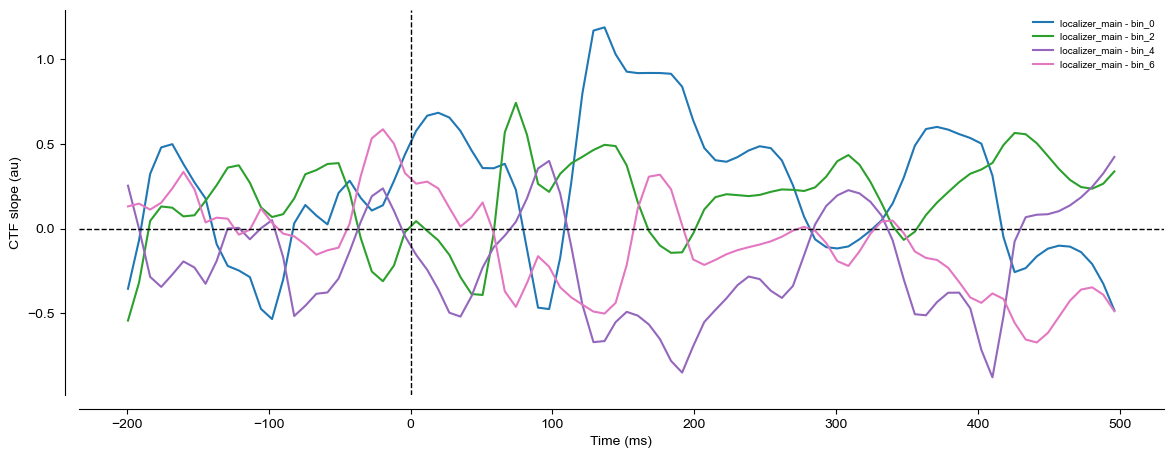

In [8]:
fig = plt.figure(figsize=(14, 5))
# this needs to be integrated into plot_ctf_timecoursve such that all pins are plotted in one figure, 
plot_ctf_timecourse(ctf_param, output = 'voltage_slopes',plot_bins=True, timecourse = '1d', stats = 'perm')
#for i in range(8):
#    plt.plot(ctf_param['localizer_main']['voltage_slopes'][0,:,i], label = i)
#plt.legend()
display(fig)


In [46]:
# Train on localizer, test on homogeneous main displays (i.e., without a distractor and a target)
# ping analysis
# figure out how this works in CTF
# Run CTF encoding for all subjects (1-7)

print('\n📊 Image location across all subjects')
for subject_id in range(1, 8):
    try:
        # Load data for this subject
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            subject_id, 'ses_01_main', 'main', eye_dict
        )

        df_sj['display_type'] = 'homogeneous'
        df_sj.loc[((df_sj.target_presence != 'absent') | 
                  (df_sj.distractor_presence != 'absent')) & 
                  (df_sj.block_type == 'main')
                  , 'display_type'] =  'heterogeneous'


        ctf_o = CTF(
            sj=subject_id, epochs=epochs_sj, df=df_sj, to_decode='img_loc',
            nr_bins=8, nr_chans=8, elec_oi='all', filter=8,
            avg_ch=True, baseline=(-0.2, 0), downsample=128,
            ctf_param = 'von_mises',
        )

        ctf_o.spatial_ctf(
            pos_labels='all', cnds = dict(block_type=[['localizer'], ['main']]),
            window_oi=(-0.2, 0.5), freqs='broadband',
            excl_factor = dict(display_type = ['heterogeneous']),
            special_loc = int(df_sj.high_prob_dist.iloc[0]),
            f_name = 'ctf_ping')

        
        print(f'  ✓ Subject {subject_id} complete')
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed')


📊 Image location across all subjects
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Creating bassiset with sin_power  7
Dropped 1425 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Uppe

In [47]:
# read in all ping data
ctfs_ping = FolderStructure().read_ctfs(ctf_folder_path=['img_loc'], output_type='param',ctf_name = 'ctf_ping', sjs = 'all')

Times converted from seconds to milliseconds


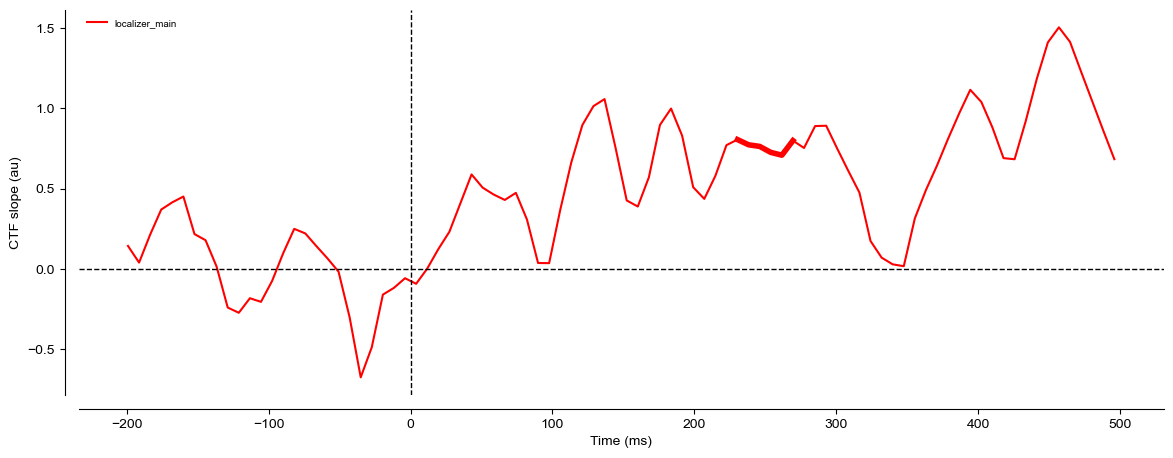

In [51]:
# show ping data
fig = plt.figure(figsize=(14, 5))
plot_ctf_timecourse(ctfs_ping, output = 'voltage_amps', timecourse = '1d', stats = 'ttest', colors = 'red')
display(fig)
